<a href="https://colab.research.google.com/github/PARZIVAL283/AI-based-plastic-waste-detection-in-water-bodies/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 - Setup the Project

**Step 1: checking T4 GPU**

In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Step 2: Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 3: Go to your project folder and Check files**

In [3]:
import os
project_path = "/content/drive/My Drive/Computer Vision Project"
os.chdir(project_path)
print(os.getcwd())
os.listdir()

/content/drive/My Drive/Computer Vision Project


['Project.ipynb', 'Dataset', 'Marine_Debris_YOLO']

# Dataset Analysis

DATASET INFORMATION

Dataset Path:
/content/drive/My Drive/Computer Vision Project

Folder Structure:

Computer Vision Project/
    Project.ipynb
    Dataset/
        marine debris images dataset/
            README.roboflow.txt
            README.dataset.txt
            train/
                IMG_0034_JPG.rf.ccfb898b22e1df47ff11f0f91b5d5499.jpg
                IMG_0037_JPG.rf.500e36ebd177e069553bb0df3b9fab78.jpg
                IMG_0038_JPG.rf.806bf0d58fb3b2323c95cdf68586fbbb.jpg
                IMG_0035_JPG.rf.01e7d05d645440e8e1c63205e5823994.jpg
                IMG_0036_JPG.rf.acd72953574c5b0eb7a33f1bb8b6e3df.jpg
            valid/
                marine-debris-188-_jpg.rf.ba10aea7ae479d126de21e9bb4dff6d3.jpg
                _classes.csv
                marine-debris-185-_jpg.rf.6ffd87a3ec3058d9353b1be3dafdb566.jpg
                marine-debris-200-_jpg.rf.227cedeee9b8dc55ccebacaabc54db57.jpg
                marine-debris-202-_jpg.rf.b48122c9ed5589565e4ff9902e3d93e6.jpg
        mari

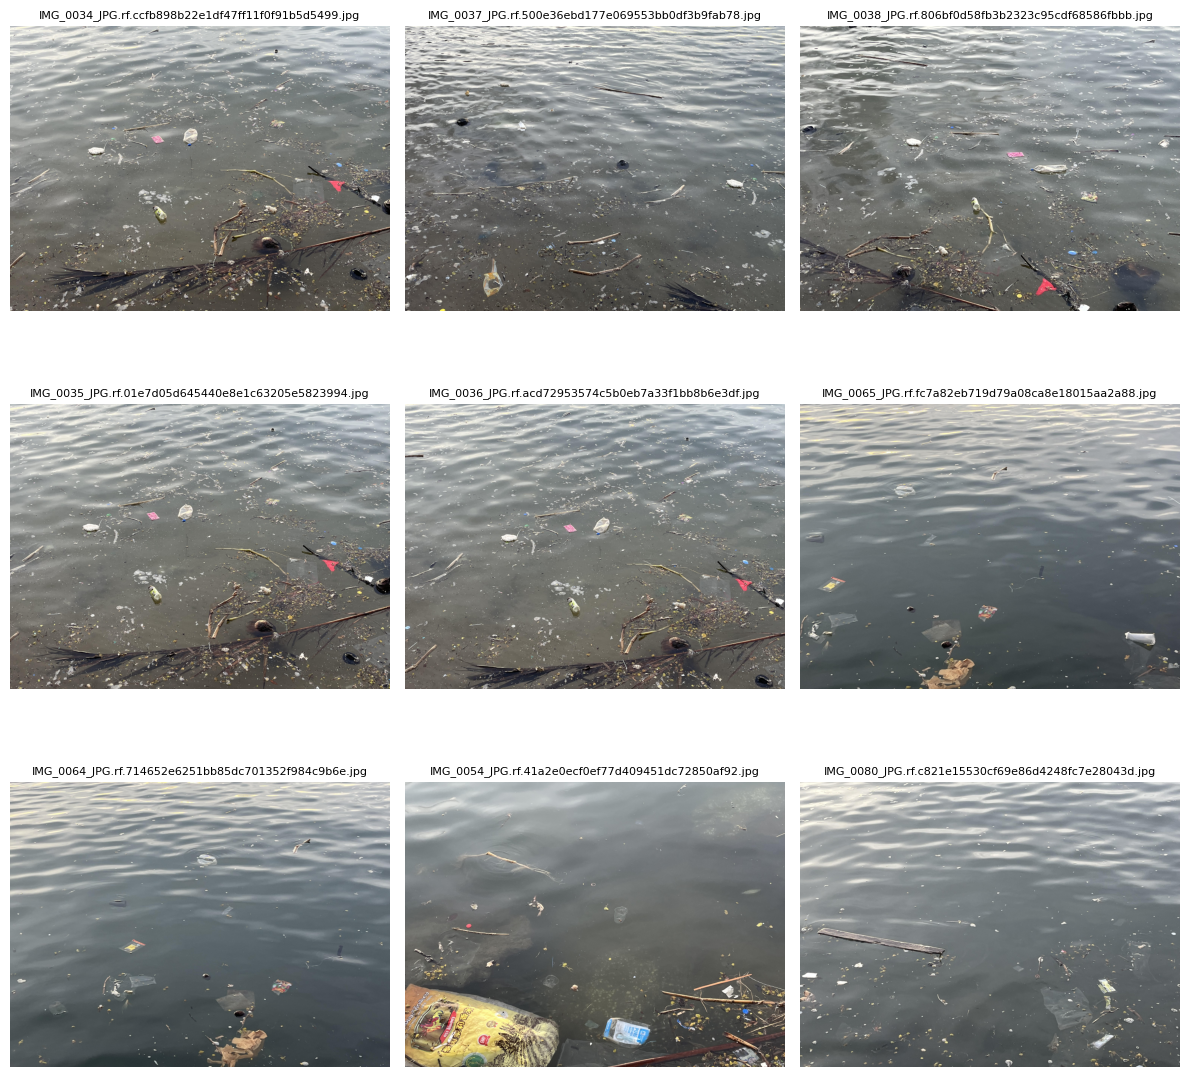


SUMMARY
                Property  Value
0           Total Images   1725
1          Image Formats      1
2  Different Resolutions     17
3       Corrupted Images      0
4  JSON Annotation Files      2


In [4]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# ==========================================================
# CHANGE THIS PATH IF NECESSARY
# ==========================================================
DATASET_PATH = "/content/drive/My Drive/Computer Vision Project"

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("="*70)
print("DATASET INFORMATION")
print("="*70)

print(f"\nDataset Path:\n{DATASET_PATH}")

print("\nFolder Structure:\n")

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")

# ==========================================================
# IMAGE INFORMATION
# ==========================================================

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

image_paths = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("\n" + "="*70)
print("IMAGE INFORMATION")
print("="*70)

print(f"Total Images : {len(image_paths)}")

# Image formats
formats = Counter()

# Image sizes
resolutions = Counter()

corrupted = []

for img_path in image_paths:

    try:
        img = Image.open(img_path)

        formats[img.format] += 1

        resolutions[f"{img.width}x{img.height}"] += 1

    except:
        corrupted.append(img_path)

print("\nImage Formats")

for k,v in formats.items():
    print(f"{k:10} {v}")

print("\nTop 10 Image Resolutions")

for res,count in resolutions.most_common(10):
    print(f"{res:15} {count}")

print("\nCorrupted Images :", len(corrupted))

# ==========================================================
# FILE SIZE
# ==========================================================

sizes = []

for img in image_paths:
    sizes.append(os.path.getsize(img)/(1024*1024))

print("\nAverage Image Size : %.2f MB"%(sum(sizes)/len(sizes)))
print("Smallest Image     : %.2f MB"%(min(sizes)))
print("Largest Image      : %.2f MB"%(max(sizes)))

# ==========================================================
# COCO INFORMATION
# ==========================================================

print("\n" + "="*70)
print("COCO ANNOTATIONS")
print("="*70)

json_files=[]

for root,dirs,files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".json"):
            json_files.append(os.path.join(root,file))

if len(json_files)==0:

    print("No COCO Annotation Found.")

else:

    for jf in json_files:

        print("\n--------------------------------")
        print(jf)

        with open(jf,'r') as f:
            coco=json.load(f)

        print("\nImages      :",len(coco['images']))
        print("Annotations :",len(coco['annotations']))
        print("Categories  :",len(coco['categories']))

        print("\nClasses")

        for c in coco['categories']:
            print(c)

        counter=Counter()

        for ann in coco['annotations']:
            counter[ann['category_id']]+=1

        print("\nAnnotations per Class")

        for cat in coco['categories']:
            cid=cat['id']
            print(f"{cat['name']:20} {counter[cid]}")

# ==========================================================
# SAMPLE IMAGES
# ==========================================================

print("\n" + "="*70)
print("SAMPLE IMAGES")
print("="*70)

sample=image_paths[:9]

plt.figure(figsize=(12,12))

for i,img_path in enumerate(sample):

    img=Image.open(img_path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(os.path.basename(img_path),fontsize=8)

    plt.axis("off")

plt.tight_layout()

plt.show()

# ==========================================================
# SUMMARY
# ==========================================================

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

summary=pd.DataFrame({

    "Property":[
        "Total Images",
        "Image Formats",
        "Different Resolutions",
        "Corrupted Images",
        "JSON Annotation Files"
    ],

    "Value":[
        len(image_paths),
        len(formats),
        len(resolutions),
        len(corrupted),
        len(json_files)
    ]

})

print(summary)

# Data Visualization


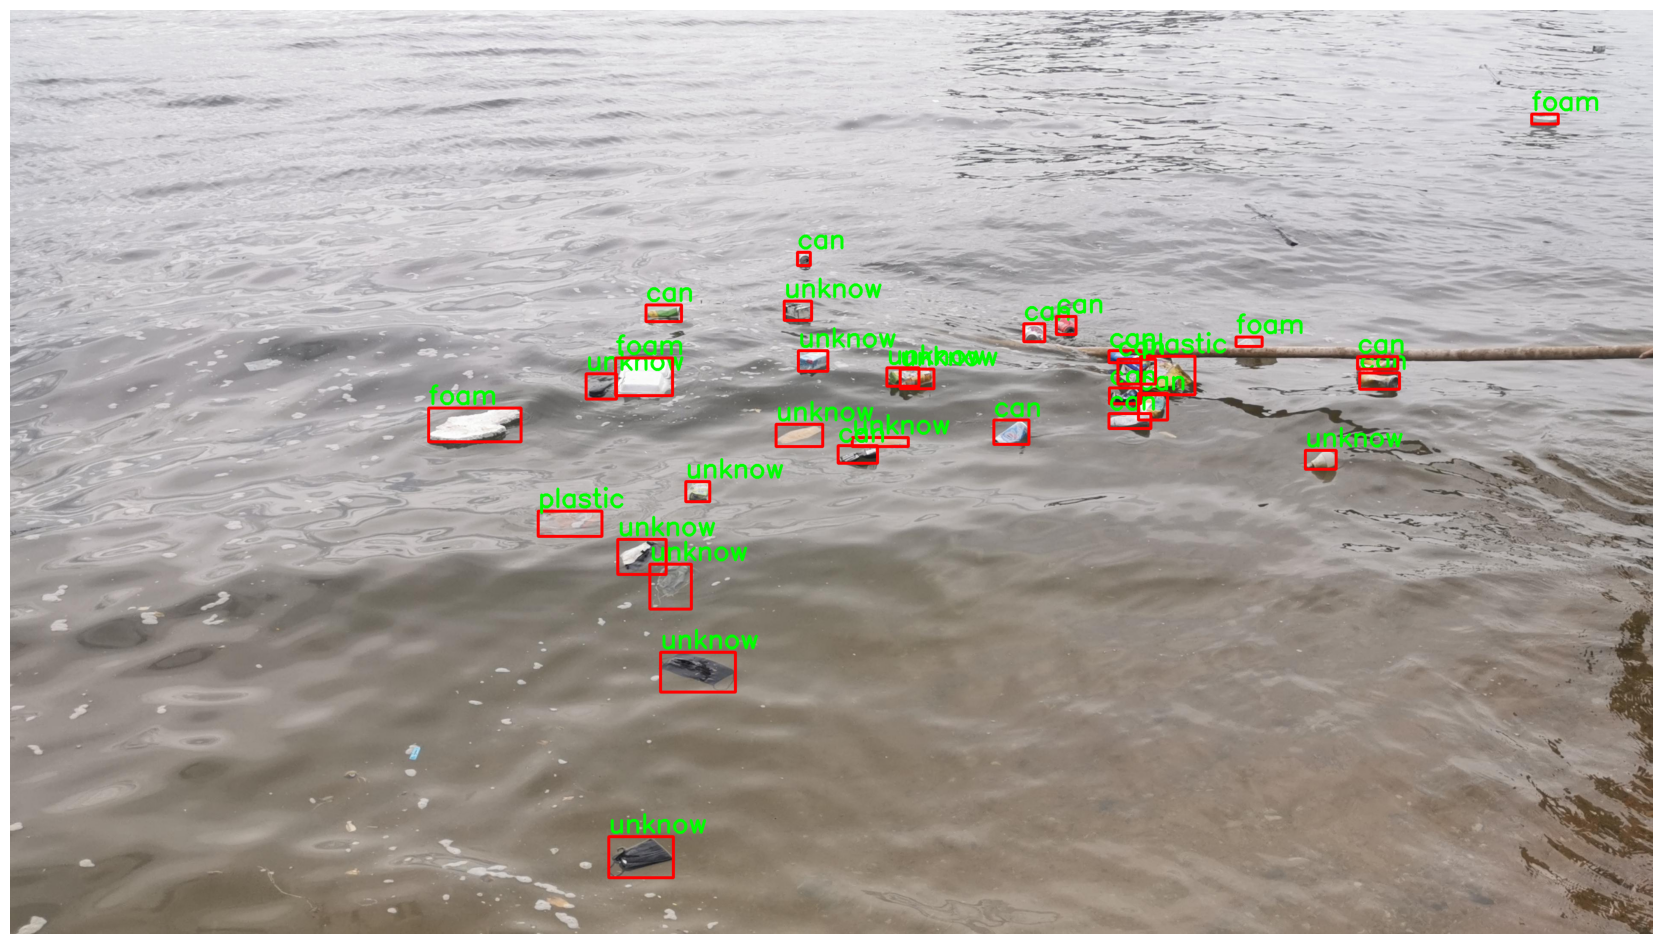

In [6]:
import json
import random
import cv2
import matplotlib.pyplot as plt
import os

# Paths
BASE_DIR = "/content/drive/My Drive/Computer Vision Project"
SOURCE_DIR = os.path.join(BASE_DIR, "Dataset", "marine debris object detection")
train_dir = os.path.join(SOURCE_DIR, "train")
annotation_file = os.path.join(train_dir, "_annotations.coco.json")

# Load COCO annotations
with open(annotation_file, "r") as f:
    coco = json.load(f)

categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Group annotations by image
annotations_per_image = {}
for ann in coco["annotations"]:
    annotations_per_image.setdefault(ann["image_id"], []).append(ann)

# Pick one random image
img_info = random.choice(coco["images"])

img_path = os.path.join(train_dir, img_info["file_name"])

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

anns = annotations_per_image.get(img_info["id"], [])

for ann in anns:

    x, y, w, h = map(int, ann["bbox"])

    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 5)

    cv2.putText(
        image,
        categories[ann["category_id"]],
        (x, max(40, y-10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        2,
        (0,255,0),
        5
    )

plt.figure(figsize=(18,12))
plt.imshow(image)
plt.axis("off")
plt.show()

**Bar Graph**

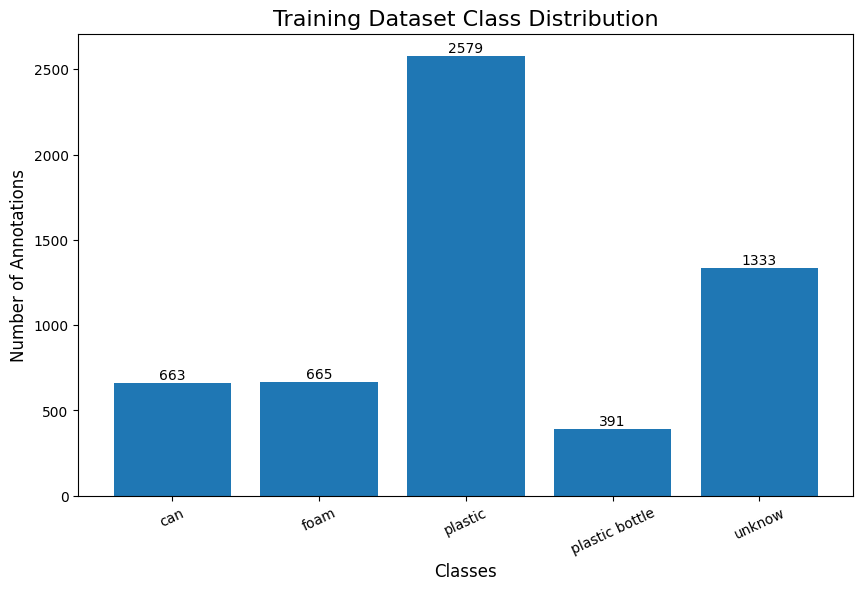

In [7]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import os

BASE_DIR = "/content/drive/My Drive/Computer Vision Project"
SOURCE_DIR = os.path.join(BASE_DIR, "Dataset", "marine debris object detection")
annotation_file = os.path.join(SOURCE_DIR, "train", "_annotations.coco.json")

with open(annotation_file, "r") as f:
    coco = json.load(f)

# Category names
categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Count annotations
counter = Counter()

for ann in coco["annotations"]:
    counter[ann["category_id"]] += 1

labels = []
values = []

for cid in sorted(categories.keys()):
    if counter[cid] > 0:
        labels.append(categories[cid])
        values.append(counter[cid])

plt.figure(figsize=(10,6))
plt.bar(labels, values)

plt.title("Training Dataset Class Distribution", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Annotations", fontsize=12)

plt.xticks(rotation=25)

for i, v in enumerate(values):
    plt.text(i, v+20, str(v), ha="center")

plt.show()

**Pie Chart**

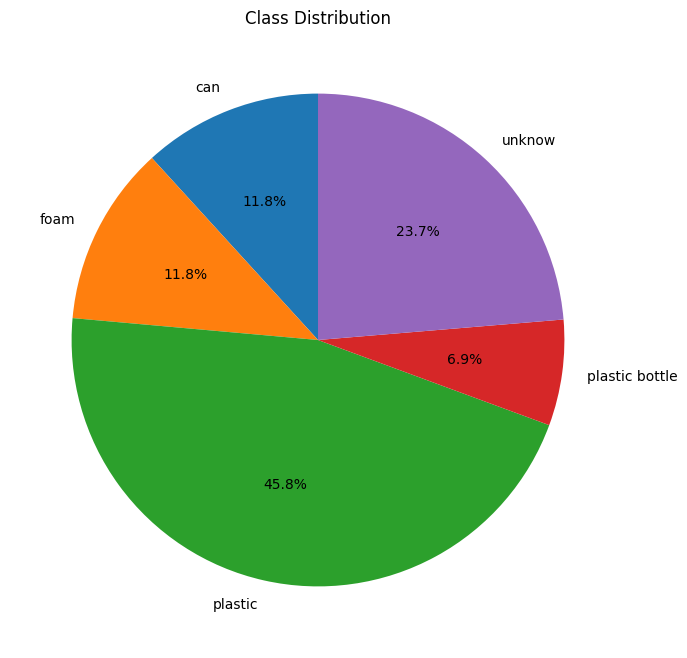

In [9]:
plt.figure(figsize=(8,8))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution")

plt.show()

# Data Preparation

In [10]:
# Install Ultralytics (YOLO)
!pip install -q ultralytics

# Check installation
import ultralytics
print("Ultralytics Version:", ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics Version: 8.4.117


**Verify GPU**

In [11]:
import torch

print("CUDA Available :", torch.cuda.is_available())
print("GPU Name :", torch.cuda.get_device_name(0))

CUDA Available : True
GPU Name : Tesla T4


**Create Output Folders**

In [12]:
import os

BASE_DIR = "/content/drive/My Drive/Computer Vision Project"

OUTPUT_DIR = os.path.join(BASE_DIR, "Marine_Debris_YOLO")

folders = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels"
]

for folder in folders:
    os.makedirs(os.path.join(OUTPUT_DIR, folder), exist_ok=True)

print("Folders created successfully!")

print("\nFolder Structure:")

for root, dirs, files in os.walk(OUTPUT_DIR):
    print(root)

Folders created successfully!

Folder Structure:
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train/images
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/train/labels
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/images
/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/valid/labels


**Converting COCO to YOLO**

In [13]:
import os
import json
import shutil

BASE_DIR = "/content/drive/My Drive/Computer Vision Project"

SOURCE_DIR = os.path.join(BASE_DIR,
                          "Dataset",
                          "marine debris object detection")

OUTPUT_DIR = os.path.join(BASE_DIR,
                          "Marine_Debris_YOLO")


def convert_dataset(split):

    image_folder = os.path.join(SOURCE_DIR, split)

    annotation_file = os.path.join(
        image_folder,
        "_annotations.coco.json"
    )

    with open(annotation_file, "r") as f:
        coco = json.load(f)

    images = {img["id"]: img for img in coco["images"]}

    annotations = {}

    for ann in coco["annotations"]:
        annotations.setdefault(
            ann["image_id"], []
        ).append(ann)

    converted = 0

    for image_id, image_info in images.items():

        image_name = image_info["file_name"]

        width = image_info["width"]

        height = image_info["height"]

        src_image = os.path.join(
            image_folder,
            image_name
        )

        dst_image = os.path.join(
            OUTPUT_DIR,
            split,
            "images",
            image_name
        )

        shutil.copy(src_image, dst_image)

        label_path = os.path.join(
            OUTPUT_DIR,
            split,
            "labels",
            image_name.replace(".jpg", ".txt")
        )

        with open(label_path, "w") as f:

            for ann in annotations.get(image_id, []):

                x, y, w, h = ann["bbox"]

                x_center = (x + w / 2) / width

                y_center = (y + h / 2) / height

                w /= width

                h /= height

                class_id = ann["category_id"] - 1

                f.write(
                    f"{class_id} "
                    f"{x_center:.6f} "
                    f"{y_center:.6f} "
                    f"{w:.6f} "
                    f"{h:.6f}\n"
                )

        converted += 1

    print(f"{split.upper()} converted successfully!")
    print(f"Images converted: {converted}")


convert_dataset("train")
convert_dataset("valid")

TRAIN converted successfully!
Images converted: 445
VALID converted successfully!
Images converted: 130


**Create data.yaml**

In [14]:
yaml_text = """
path: /content/drive/MyDrive/Computer Vision Project/Marine_Debris_YOLO

train: train/images
val: valid/images

names:
  0: can
  1: foam
  2: plastic
  3: plastic bottle
  4: unknow
"""

yaml_path = "/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print("data.yaml created successfully!")

data.yaml created successfully!


**Verify the Conversion**

In [17]:
import os

base = "/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO"

for split in ["train", "valid"]:

    img_path = os.path.join(base, split, "images")
    lbl_path = os.path.join(base, split, "labels")

    images = len([f for f in os.listdir(img_path)
                  if f.endswith((".jpg", ".png", ".jpeg"))])

    labels = len([f for f in os.listdir(lbl_path)
                  if f.endswith(".txt")])

    print(f"{split.upper()}")
    print(f"Images : {images}")
    print(f"Labels : {labels}")
    print("-"*30)

TRAIN
Images : 445
Labels : 445
------------------------------
VALID
Images : 130
Labels : 130
------------------------------


# Data Training

**Training Code**

we are using YOLO version 11 model

In [18]:
from ultralytics import YOLO

# Load pretrained YOLO model
model = YOLO("yolo11n.pt")

# Train
results = model.train(
    data="/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml",
    epochs=50, #early stopping will prevent overfitting
    imgsz=640, #standard for YOLO
    batch=16, #appropriate for T4 GPU
    device=0,
    workers=2,
    project="/content/drive/My Drive/Computer Vision Project",
    name="Marine_Debris_Detection",
    pretrained=True, #My dataset is pre trained, used for fine tuning
    patience=15, # stops trainig when datset performance stops improving
    verbose=True
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/Computer Vision Project/Marine_Debris_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_